# Sales Data Visualization of Companies

This project analyzes and visualizes corporate sales data to provide clear business insights. Using Pandas and Matplotlib, it reshapes data to generate product summary pivot tables, charts top 5 companies by order quantity, and creates scatterplots comparing price versus quantity for specific companies.

Use sales\-data sheet from assignment\-data.xlsx and do the following tasks:

The Managing Director found that there is no clarity in sales\-data. He likes to see clear visualization of data in various dimensions. 

He instructed his junior data scientist “Mr.Bean” to reshape the data.


# Part 1

Mr. Bean decided to display the product details produced by every company, along with supervisor detail. 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt # ginagamit para sa pag-graph o pag-visualize ng data.

# Kukunin ang data mula sa 'sales-data' na sheet ng assignment-data.xlsx
# Ilalagay ito sa variable na 'df' para magamit natin
df = pd.read_excel("assignment-data.xlsx", sheet_name='sales-data')

# Gumagawa tayo ng pivot table para mas madaling makita ang summary ng data
pivot_table = df.pivot_table(
    values='Price',                        # Ang 'Price' ang kukunin natin para sa total o summary
    index=['supervisor', 'company-name'],  # Igu-grupo according sa 'supervisor' at 'company-name'
    columns='Product-detail',              # Ang bawat 'Product-detail' ay gagawing column
    aggfunc='sum',                         # Ia-add (total) natin ang presyo para sa bawat kombinasyon
    fill_value=0                           # Kung walang data, papalitan ng 0 para walang blanko
)

# Ipapakita ang ginawa nating pivot table
pivot_table

Product-detail               Monitor  Software  printer  search engine
supervisor     company-name                                           
David Anderson Adobe               0         0        0          23000
               Infosys          4000         0        0          69000
               Microsoft           0         0     5000              0
               Oracle              0         0        0          90000
               SAP                 0         0        0          75000
               XYZ company         0      9000     3000              0
Peter Prince   ABC ltd             0         0        0          25000
               Apple               0     20000     6000          40000
               Facebook            0         0        0          54000
               Google              0         0        0          45000
               HCL                 0     12000     8000          43000

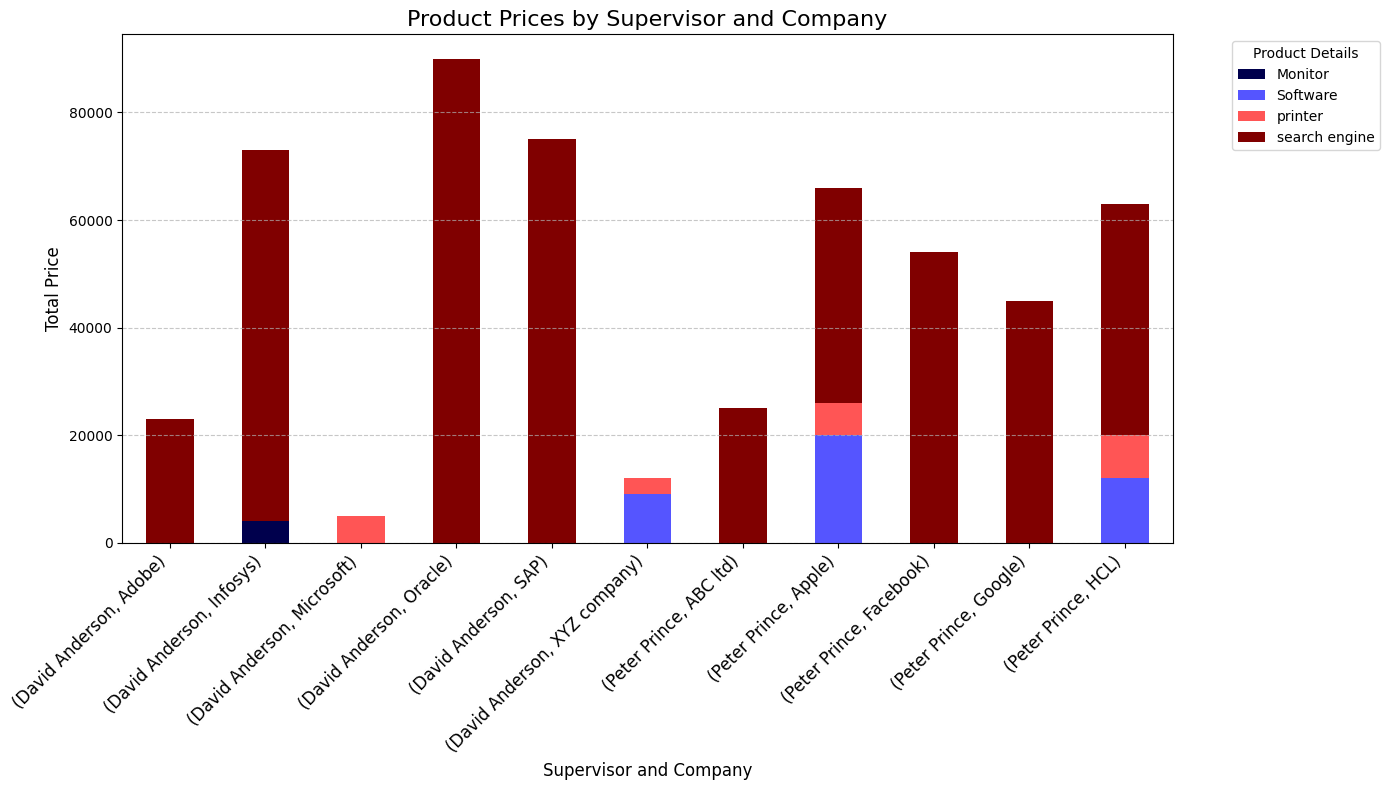

In [32]:
# I-plot ang data bilang stacked bar chart gamit ang matplotlib
pivot_table.plot(
    kind='bar',       # I-plot bilang bar chart
    figsize=(14, 8),  # Laki ng chart (width=14, height=8)
    stacked=True,     # Para maging stacked (isang bar na may layers)
    colormap='seismic'  # Kulay ng mga bar (pwedeng palitan depende sa gusto natin)
)

# I-customize ang itsura ng chart
plt.title("Product Prices by Supervisor and Company", fontsize=16)  # Title ng chart
plt.xlabel("Supervisor and Company", fontsize=12)                   # Label sa x-axis
plt.ylabel("Total Price", fontsize=12)                              # Label sa y-axis
plt.xticks(rotation=45, ha='right', fontsize=12)                    # Paikot ng labels sa x-axis para mag-fit
plt.legend(
    title="Product Details",   # Title ng legend para may guide
    bbox_to_anchor=(1.05, 1),  # Ilipat ang legend sa gilid
    loc='upper left'           # Posisyon ng legend
)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Maglagay ng grid lines sa y-axis
plt.tight_layout()  # Para ayusin ang layout ng chart (iwas overlap)

# Ipakita ang chart
plt.show()

# Part 2

Mr.Bean decided to show the top 5 companies that have the most 'total\-quantity' ordered. 

Expected output is as follows


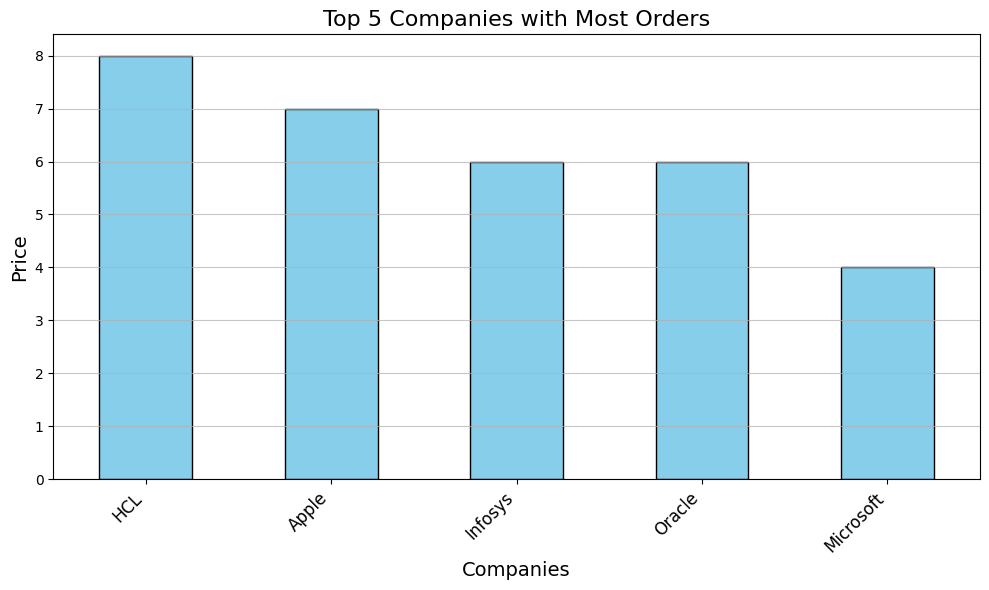

In [33]:
# I-group ang data according sa 'company-name' at i-calculate ang total quantity na inorder ng bawat company
top_companies = df.groupby('company-name')['total-quantity'].sum().sort_values(ascending=False).head(5)

# I-plot ang top 5 na companies
plt.figure(figsize=(10, 6))                                        # Laki ng chart (width=10, height=6)
top_companies.plot(kind='bar', color='skyblue', edgecolor='black') # Bar chart, skyblue ang kulay, may black na edge
plt.title("Top 5 Companies with Most Orders", fontsize=16)         # Title ng chart
plt.xlabel("Companies", fontsize=14)                               # Label sa x-axis
plt.ylabel("Price", fontsize=14)                                   # Label sa y-axis
plt.xticks(rotation=45, ha='right', fontsize=12)                   # Paikot ng labels sa x-axis para hindi mag-overlap
plt.grid(axis='y', linestyle='-', alpha=0.7)                       # lagay ng grid sa y-axis para makita pagkakapantay
plt.tight_layout()                                                 # Para maiwasan ang overlap ng chart at labels

# Ipakita ang chart
plt.show()

# Part 3

Further, Mr.Bean has created a scatterplot showing 'total\-quantity' vs Price for 3 companies; Apple, HCL and Infosys.

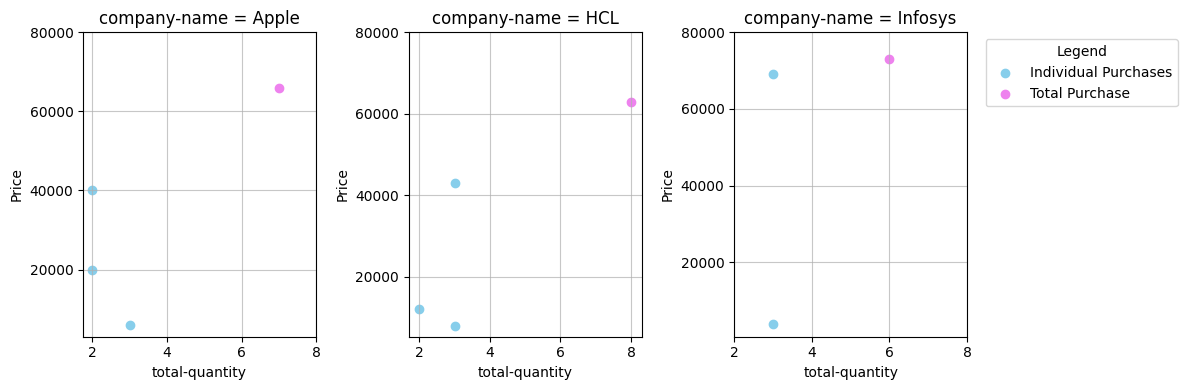

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("assignment-data.xlsx", sheet_name='sales-data')

# I-filter ang data para sa top 3 companies ayon sa total quantity
top_3 = df.groupby('company-name')['total-quantity'].sum().nlargest(3).index

# Arrangement ng mga kumpanya na magpapakita gamit list
companies = ['Apple', 'HCL', 'Infosys']

# I-filter ang data para sa mga napiling kumpanya
filtered_data = df[df['company-name'].isin(companies)]

# I-Calculate ang total Price at total Quantity per company para sa mga plots
total_data = filtered_data.groupby('company-name').agg({
    'Price': 'sum',          # Total Price
    'total-quantity': 'sum'  # Total Quantity
}).reset_index()

# Ire-ready ang figure at axes para sa plotting
fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 3 scatter side by side

# Gagawa ng mga individual scatter points at total points para sa bawat companies
for i, company in enumerate(companies):
    company_data = filtered_data[filtered_data['company-name'] == company]  # Kunin ang data sa companies
    totals = total_data[total_data['company-name'] == company].iloc[0]      # Total ng companies

    # Individual scatter points (blue dots)
    axs[i].scatter(company_data['total-quantity'], company_data['Price'], color='skyblue', label='Individual Purchases')

    # Total point (violet dots)
    axs[i].scatter(totals['total-quantity'], totals['Price'], color='violet', label='Total Purchase')

    # Labels, ticks, at titles
    axs[i].set_xlabel('total-quantity')              # Label sa x-axis
    axs[i].set_ylabel('Price')                       # Label sa y-axis
    axs[i].set_xticks([2, 4, 6, 8])                  # Custom na ticks sa x-axis
    axs[i].set_yticks([20000, 40000, 60000, 80000])  # Custom na ticks sa y-axis
    axs[i].set_title(f"company-name = {company}")    # Title para sa bawat plot
    axs[i].grid(axis='x', linestyle='-', alpha=0.7)  # Grid sa x-axis
    axs[i].grid(axis='y', linestyle='-', alpha=0.7)  # Grid sa y-axis

# Maglagay ng legend bilang guide
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')

# Aayusin ang layout para hindi ulit mag-overlap
plt.tight_layout()

# Ipakita ang plot
plt.show()